# VSH basis vectors on a mesh model

Render an icosphere mesh (same style as `plot_mesh.plot_3D` in MESH mode) with the three vector spherical harmonic basis directions drawn at a single surface point, for several $(\ell, m)$ modes side by side:

- Radial: $R_\ell^m = Y_\ell^m\,\hat r$
- Spheroidal: $S_\ell^m = \nabla_t Y_\ell^m$
- Toroidal: $T_\ell^m = \hat r \times \nabla_t Y_\ell^m$

The radial direction is $\hat r$ for any $(\ell, m)$ (only its amplitude $Y_\ell^m$ changes); the spheroidal and toroidal directions **rotate within the tangent plane** as $(\ell, m)$ changes.

Edit the parameters in the **Parameters** cell, then re-run the **Plot** cell. The mesh is only rebuilt if you change `N_VERTICES`.

## Setup

In [1]:
import os, sys
from pathlib import Path

# Make the in-tree spice package importable without an editable install.
ROOT = Path.cwd().parent if Path.cwd().name == "tutorial" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

# spice.__init__ does this too, but set before the first jax import.
if sys.platform == "darwin":
    os.environ.setdefault("JAX_PLATFORMS", "cpu")

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import art3d, proj3d

from spice.models import IcosphereModel
from spice.models.utils import (
    spherical_harmonic_tangential_gradient,
    spherical_harmonic_toroidal,
)

## Parameters

Tweak these to change the plot.

In [2]:
# VSH modes to compare, as (l, m) tuples. One subplot per mode.
MODES = [(1, 0), (2, 1), (3, 2)]

# Mesh resolution (icosphere vertex count). 642 is smooth and fast.
N_VERTICES = 642

# Anchor point on the sphere (spherical coords, degrees).
THETA_DEG = 30.0   # colatitude from +z axis
PHI_DEG   = 0.0    # longitude in x-y plane

# Camera view
VIEW_ELEV = 20
VIEW_AZIM = -60

# Visual style
ARROW_LEN   = 0.65
MESH_COLOR  = "white"
EDGE_COLOR  = (0.0, 0.0, 0.0, 0.18)
MESH_LINEWIDTH = 1
LABEL_PAD   = 0.20                # axes-fraction offset from arrow tip

# Save result?
SAVE_PATH = Path.cwd() / "vsh_basis_vectors.png"   # set to None to skip saving

## Helpers

In [3]:
def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-12 else v


def vsh_basis_at_point(l, m, coord):
    """Return (r_hat, spheroidal_unit, toroidal_unit) at a single point."""
    r_hat = np.asarray(coord / jnp.linalg.norm(coord, axis=1, keepdims=True))[0]
    grad_t = np.asarray(spherical_harmonic_tangential_gradient(m, l, coord))[0]
    toro   = np.asarray(spherical_harmonic_toroidal(m, l, coord))[0]
    return r_hat, unit(grad_t), unit(toro)

## Build the mesh

Only needs to be re-run if `N_VERTICES` changes.

In [4]:
mesh = IcosphereModel.construct(
    n_vertices=N_VERTICES,
    radius=1.0,
    mass=1.0,
    parameters=jnp.array([5700.0, 4.4]),
    parameter_names=["teff", "log_g"],
)
radius = float(mesh.radius)
faces = np.asarray(mesh.mesh_elements)
print(f"mesh: {faces.shape[0]} triangles, radius={radius}")

[spice] IcosphereModel constructed in 1.0 s
mesh: 1280 triangles, radius=1.0


## Compute the anchor point

In [5]:
theta0 = np.deg2rad(THETA_DEG)
phi0   = np.deg2rad(PHI_DEG)
point = np.array([
    np.sin(theta0) * np.cos(phi0),
    np.sin(theta0) * np.sin(phi0),
    np.cos(theta0),
]) * radius
coord = jnp.asarray(point)[None, :]
print(f"anchor point = {point}")

anchor point = [0.5       0.        0.8660254]


## Plot

Three subplots, one per mode in `MODES`.

wrote /Users/mjablons/code/spice/tutorial/vsh_basis_vectors.png


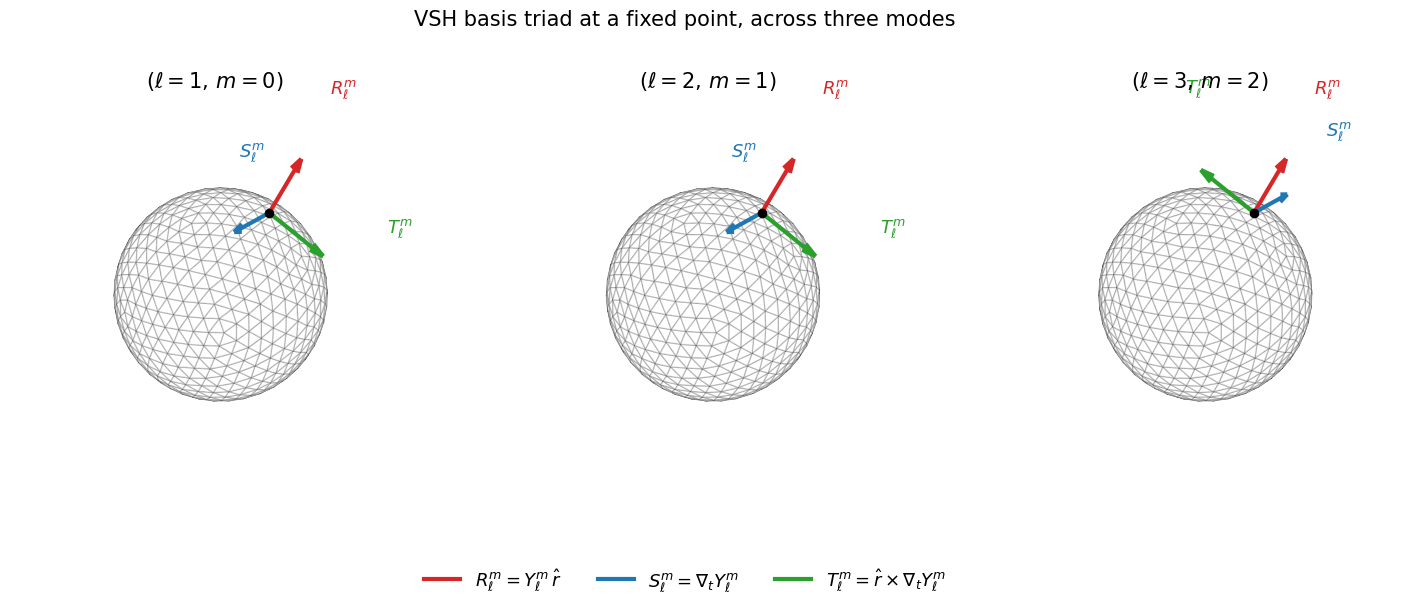

In [6]:
def render_mode(ax, l, m, point, radius, faces):
    r_hat, s_unit, t_unit = vsh_basis_at_point(l, m, jnp.asarray(point)[None, :])
    v_radial     = r_hat  * ARROW_LEN
    v_spheroidal = s_unit * ARROW_LEN
    v_toroidal   = t_unit * ARROW_LEN

    coll = art3d.Poly3DCollection(
        faces, facecolors=MESH_COLOR, edgecolor=EDGE_COLOR, linewidths=MESH_LINEWIDTH,
    )
    ax.add_collection(coll)

    lim = 1.15 * radius
    ax.set_xlim3d(-lim, lim)
    ax.set_ylim3d(-lim, lim)
    ax.set_zlim3d(-lim, lim)
    ax.set_box_aspect([1.0, 1.0, 1.0])
    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)
    ax.set_axis_off()

    ax.computed_zorder = False
    coll.set_zorder(1)

    tail = point * 1.03
    arrows = [
        (v_radial,     "#d62728", r"$R_\ell^m$"),
        (v_spheroidal, "#1f77b4", r"$S_\ell^m$"),
        (v_toroidal,   "#2ca02c", r"$T_\ell^m$"),
    ]
    for vec, color, _label in arrows:
        q = ax.quiver(
            tail[0], tail[1], tail[2],
            vec[0], vec[1], vec[2],
            color=color, linewidth=3.0, arrow_length_ratio=0.22,
        )
        q.set_zorder(10)

    ax.scatter([tail[0]], [tail[1]], [tail[2]], color="black", s=35, zorder=11)
    return arrows, tail


def place_labels(fig, ax, arrows, tail):
    proj = ax.get_proj()

    def to_axes_fraction(p):
        x2, y2, _ = proj3d.proj_transform(p[0], p[1], p[2], proj)
        disp = ax.transData.transform((x2, y2))
        return np.array(ax.transAxes.inverted().transform(disp))

    sphere_centre_frac = to_axes_fraction(np.zeros(3))
    for vec, color, label in arrows:
        tip = tail + vec
        tip_frac = to_axes_fraction(tip)
        outward = tip_frac - sphere_centre_frac
        norm = float(np.linalg.norm(outward))
        if norm < 1e-6:
            label_frac = tip_frac + np.array([0.08, 0.08])
        else:
            label_frac = tip_frac + (outward / norm) * LABEL_PAD
        ax.text2D(
            label_frac[0], label_frac[1], label,
            transform=ax.transAxes,
            color=color, fontsize=13, ha="center", va="center",
            weight="bold",
        )


n = len(MODES)
fig = plt.figure(figsize=(6 * n, 6))
axes = [fig.add_subplot(1, n, i + 1, projection="3d") for i in range(n)]

rendered = []
for ax, (l, m) in zip(axes, MODES):
    arrows, tail = render_mode(ax, l, m, point, radius, faces)
    ax.set_title(rf"$(\ell={l},\, m={m})$", fontsize=15)
    rendered.append((ax, arrows, tail))

# Label placement needs the projection matrix to be finalized — draw once,
# then place each subplot's labels.
fig.canvas.draw()
for ax, arrows, tail in rendered:
    place_labels(fig, ax, arrows, tail)

# Shared legend across all subplots (the three VSH basis symbols).
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="#d62728", lw=3, label=r"$R_\ell^m = Y_\ell^m\,\hat r$"),
    Line2D([0], [0], color="#1f77b4", lw=3, label=r"$S_\ell^m = \nabla_t Y_\ell^m$"),
    Line2D([0], [0], color="#2ca02c", lw=3, label=r"$T_\ell^m = \hat r \times \nabla_t Y_\ell^m$"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.02), fontsize=13, frameon=False)

fig.suptitle("VSH basis triad at a fixed point, across three modes", fontsize=15)

if SAVE_PATH is not None:
    fig.savefig(SAVE_PATH, dpi=150, bbox_inches="tight")
    print(f"wrote {SAVE_PATH}")

plt.show()